In [1]:
from astropy.table import Table
from astropy.io import fits
from astropy.io.fits import BinTableHDU
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [45]:
datasets = {
    "FLA": {
        "filename": "FLAMES-30Dor-6563",
        "label": "FLAMES",
        "multiply_r_by_pix_pc": False,
    },

    "FLA MUSE": {
        "filename": "FLAMES-30Dor-6563-MUSE",
        "label": "FLAMES MUSE",
        "multiply_r_by_pix_pc": False,
    },

    "FLA FP": {
        "filename": "FLAMES-30Dor-6563-SAMFP",
        "label": "FLAMES FP",
        "multiply_r_by_pix_pc": False,
    },

    "LVM MUSE": {
        "filename": "LVM-30Dor-6563-MUSE",
        "label": "LVM MUSE",
        "multiply_r_by_pix_pc": False,
    },

    "LVM FP": {
        "filename": "LVM-30Dor-6563-SAMFP",
        "label": "LVM FP",
        "multiply_r_by_pix_pc": False,
    },
    
    
    "LVM_25": {
        "filename": "LVM-30Dor-6563_25",
        "label": "LVM 25",
        "multiply_r_by_pix_pc": False,
    },

    "LVM_50": {
        "filename": "LVM-30Dor-6563_50",
        "label": "LVM 50",
        "multiply_r_by_pix_pc": False,
    },

    "LVM_100": {
        "filename": "LVM-30Dor-6563_100",
        "label": "LVM 100",
        "multiply_r_by_pix_pc": False,
    },

    "LVM_150": {
        "filename": "LVM-30Dor-6563_150",
        "label": "LVM 150",
        "multiply_r_by_pix_pc": False,
    },

    "LVM_200": {
        "filename": "LVM-30Dor-6563_200",
        "label": "LVM 200",
        "multiply_r_by_pix_pc": False,
    },

    "LVM_250": {
        "filename": "LVM-30Dor-6563_subrot-01",
        "label": "LVM 250",
        "multiply_r_by_pix_pc": False,
    },

    "MUSE": {
        "filename": "MUSE-Dor-H-bin0",
        "label": "MUSE",
        "multiply_r_by_pix_pc": True,
    },

    "SAMFP": {
        "filename": "SAMFP-30Dor-Ha-bin0",
        "label": "SAMFP",
        "multiply_r_by_pix_pc": True,
    },
}

In [46]:
datasets.items()

dict_items([('FLA', {'filename': 'FLAMES-30Dor-6563', 'label': 'FLAMES', 'multiply_r_by_pix_pc': False}), ('FLA MUSE', {'filename': 'FLAMES-30Dor-6563-MUSE', 'label': 'FLAMES MUSE', 'multiply_r_by_pix_pc': False}), ('FLA FP', {'filename': 'FLAMES-30Dor-6563-SAMFP', 'label': 'FLAMES FP', 'multiply_r_by_pix_pc': False}), ('LVM MUSE', {'filename': 'LVM-30Dor-6563-MUSE', 'label': 'LVM MUSE', 'multiply_r_by_pix_pc': False}), ('LVM FP', {'filename': 'LVM-30Dor-6563-SAMFP', 'label': 'LVM FP', 'multiply_r_by_pix_pc': False}), ('LVM_25', {'filename': 'LVM-30Dor-6563_25', 'label': 'LVM 25', 'multiply_r_by_pix_pc': False}), ('LVM_50', {'filename': 'LVM-30Dor-6563_50', 'label': 'LVM 50', 'multiply_r_by_pix_pc': False}), ('LVM_100', {'filename': 'LVM-30Dor-6563_100', 'label': 'LVM 100', 'multiply_r_by_pix_pc': False}), ('LVM_150', {'filename': 'LVM-30Dor-6563_150', 'label': 'LVM 150', 'multiply_r_by_pix_pc': False}), ('LVM_200', {'filename': 'LVM-30Dor-6563_200', 'label': 'LVM 200', 'multiply_r_by_

# Load data

In [47]:
def load_structure_function_dataset(info):
    """
    Load one FITS file containing structure-function data.

    This version:
    - reads the structure-function table from HDU='TABLE'
    - reads MOM0, MOM1, MOM2, MASK if they exist
    - reads HDU 1 as a table if HDU 1 is a BinTableHDU
    - stores everything inside the dataset dictionary
    """

    filename = info["filename"] + ".fits"

    with fits.open(filename) as hdul:

        # Copy primary header
        hdr = hdul[0].header.copy()

        # Get list of HDU names
        hdu_names = [hdu.name for hdu in hdul]

        # Store HDU names for later inspection
        info["hdu_names"] = hdu_names

        # -------------------------------------------------
        # Read HDU 1 only if it is a table
        # -------------------------------------------------
        if len(hdul) > 1 and isinstance(hdul[1], BinTableHDU):

            data_hdu1 = Table(hdul[1].data)
            frame_hdu1 = data_hdu1.to_pandas()

            info["data_hdu1"] = data_hdu1
            info["frame_hdu1"] = frame_hdu1
            info["hdu1_name"] = hdul[1].name

        # -------------------------------------------------
        # Read image HDUs if they exist
        # -------------------------------------------------
        if "MOM0" in hdu_names:
            info["mom0"] = hdul["MOM0"].data.copy()

        if "MOM1" in hdu_names:
            info["mom1"] = hdul["MOM1"].data.copy()

        if "MOM2" in hdu_names:
            info["mom2"] = hdul["MOM2"].data.copy()

        if "MASK" in hdu_names:
            info["mask_image"] = hdul["MASK"].data.copy()

    # -------------------------------------------------
    # Read structure-function table
    # -------------------------------------------------
    data = Table.read(filename, hdu="TABLE")
    frame = data.to_pandas()

    # Mask valid structure-function bins
    if "N pairs" in frame.columns:
        sf_mask = np.array(frame["N pairs"]) > 0
    else:
        sf_mask = np.ones(len(frame), dtype=bool)

    # Extract B(r)
    B = np.array(frame["Unweighted B(r)"])[sf_mask]

    # Extract r
    r = 10 ** np.array(frame["log10 r"])[sf_mask]

    # Optional physical scaling
    if info.get("multiply_r_by_pix_pc", False):

        required_keys = ["PIX", "PC"]
        missing_keys = [k for k in required_keys if k not in hdr]

        if missing_keys:
            raise KeyError(
                f"{info['filename']} requires PIX and PC scaling, "
                f"but these header keys are missing: {missing_keys}"
            )

        pix = hdr["PIX"]
        pc = hdr["PC"]

        r = r * pix * pc

        info["pix"] = pix
        info["pc"] = pc

    # Optional header values
    if "SIG2" in hdr:
        info["sig2"] = hdr["SIG2"]

    # Store table and processed structure-function arrays
    info["table"] = data
    info["frame"] = frame
    info["header"] = hdr
    info["B"] = B
    info["r"] = r
    info["sf_mask"] = sf_mask

    return info

In [48]:
for key, info in datasets.items():
    datasets[key] = load_structure_function_dataset(info)

# B(r) comparison

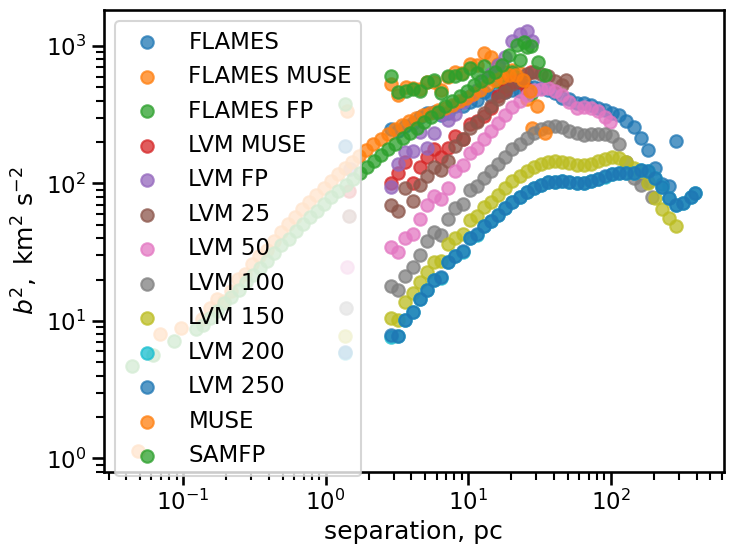

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))

for key, info in datasets.items():

    ax.scatter(
        info["r"],
        info["B"],
        label=info["label"],
        alpha=0.75,
    )

ax.legend()

ax.set(
    xscale="log",
    yscale="log",
    xlabel="separation, pc",
    ylabel=r"$b^2,\ \mathrm{km^2\ s^{-2}}$",
)

plt.show()

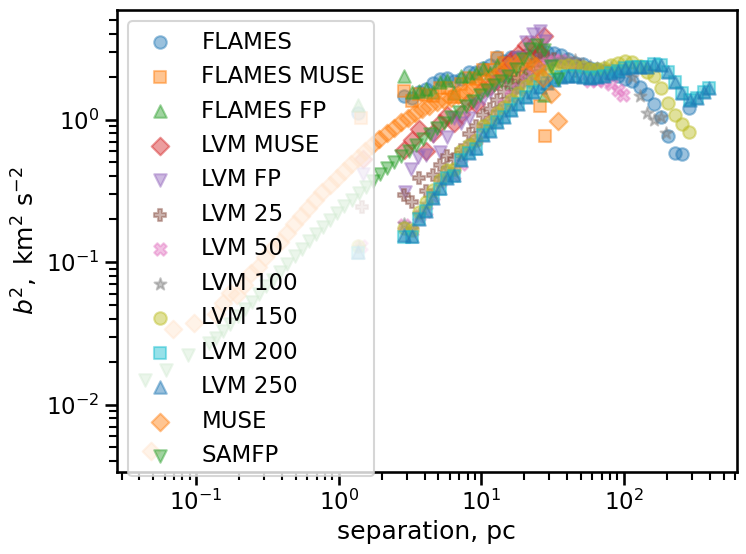

In [50]:
from itertools import cycle
markers = cycle(["o", "s", "^", "D", "v", "P", "X", "*"])

fig, ax = plt.subplots(figsize=(8, 6))

for key, info in datasets.items():

    marker = next(markers)

    ax.scatter(
        info["r"],
        info["B"]/info["sig2"],
        label=info["label"],
        alpha=0.45,
        marker=marker
    )

ax.legend()

ax.set(
    xscale="log",
    yscale="log",
    xlabel="separation, pc",
    ylabel=r"$b^2,\ \mathrm{km^2\ s^{-2}}$",
)

plt.show()

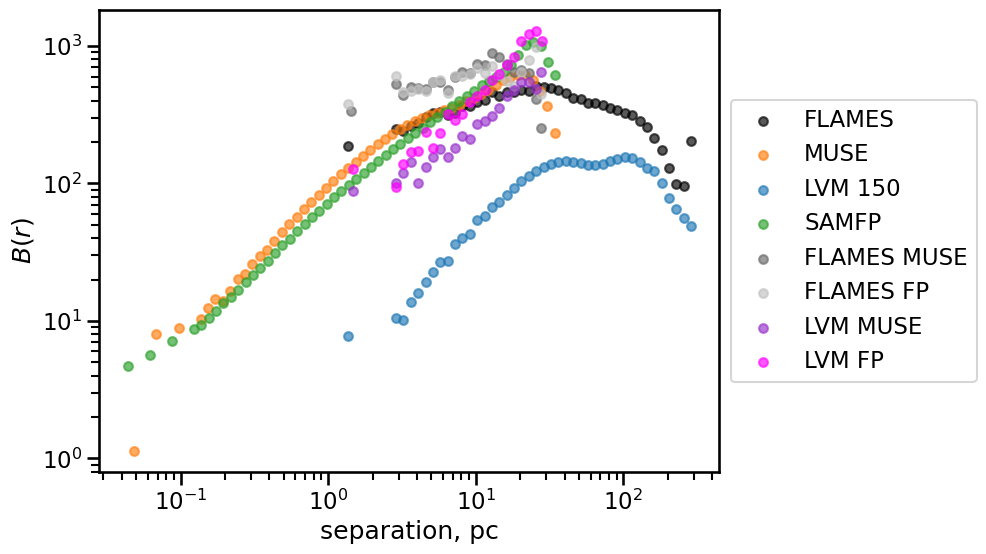

In [63]:
samples_to_plot = ["FLA", "MUSE", "LVM_150", "SAMFP","FLA MUSE", "FLA FP", "LVM MUSE", "LVM FP"]
colors = cycle(["black","tab:orange","tab:blue",'tab:green','dimgray','silver','darkorchid','magenta'])

fig, ax = plt.subplots(figsize=(8, 6))

for key in samples_to_plot:

    info = datasets[key]
    color = next(colors)

    ax.scatter(
        info["r"],
        info["B"],
        label=info["label"],
        alpha=0.65,
        color = color,
        marker = 'o',
        s = 40,
    )


ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="separation, pc",
    ylabel=r"$B(r)$",
)

plt.show()

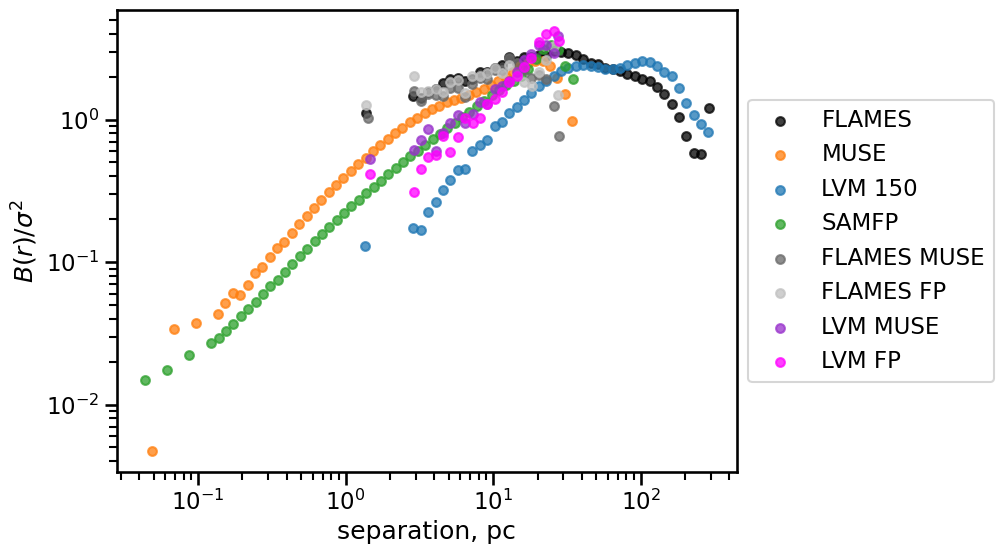

In [67]:
samples_to_plot = ["FLA", "MUSE", "LVM_150", "SAMFP","FLA MUSE", "FLA FP", "LVM MUSE", "LVM FP"]
colors = cycle(["black","tab:orange","tab:blue",'tab:green','dimgray','silver','darkorchid','magenta'])

fig, ax = plt.subplots(figsize=(8, 6))

for key in samples_to_plot:

    info = datasets[key]
    color = next(colors)

    ax.scatter(
        info["r"],
        info["B"]/info["sig2"],
        label=info["label"],
        alpha=0.75,
        color = color,
        marker = 'o',
        s = 40,
    )

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="separation, pc",
    ylabel=r"$B(r)/\sigma^2$",
)

plt.show()

# Velocity Fields

In [9]:
datasets['FLA']['frame_hdu1']

,RAdeg,DEdeg,V_mean,log_F,sigma
0,84.550875,-69.148917,-2.775576,3.980130,10.705632
1,84.634750,-69.088028,4.344645,5.050337,11.376043
2,84.852375,-69.082583,-33.764827,4.063845,10.314624
3,84.610125,-69.163389,-0.596002,3.892574,15.575936
4,84.460167,-69.170167,1.242338,4.282470,5.439301
...,...,...,...,...,...
1352,84.721708,-69.122194,-32.478608,3.087947,81.761108
1353,84.768417,-69.177750,-6.360495,3.592798,15.923745
1354,84.768417,-69.033306,5.505637,3.668402,24.747502
1355,84.768417,-69.066639,-13.473946,4.106189,16.710389


In [10]:
datasets['LVM_25']['frame_hdu1']

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
0,84.725051,-69.119368,11.224231,1.397626e+05,1.2809,281.1635,269.939269
1,84.700104,-69.124527,5.524423,2.398311e+05,1.0407,275.4064,269.881977
2,84.650000,-69.124534,-8.430731,1.572660e+05,0.9253,261.4072,269.837931
3,84.675046,-69.119382,-3.363324,3.548621e+05,0.9400,266.5319,269.895224
4,84.700080,-69.114227,5.868226,3.592220e+05,0.9993,275.8208,269.952574
...,...,...,...,...,...,...,...
369,84.701851,-69.074819,-26.106757,7.291003e+05,0.9206,244.1177,270.224457
370,84.678262,-69.080710,-10.754075,8.186586e+05,1.1806,259.4091,270.163175
371,84.654573,-69.086600,-5.684450,1.126133e+06,0.9978,264.4174,270.101850
372,84.630871,-69.092487,-0.265477,1.022772e+06,0.9713,269.7751,270.040577


In [11]:
mom0 = np.asarray(datasets["MUSE"]["mom0"], dtype=np.float64)

df_mom0 = pd.DataFrame(mom0)

df_mom0_long = (
    df_mom0.stack()
           .reset_index()
           .rename(columns={"level_0": "X", "level_1": "Y", 0: "I"})
           .dropna(subset=["I"])
)

df_mom0_long.describe()

,X,Y,I
count,330400.000000,330400.000000,330400.000000
mean,294.500000,279.500000,0.112158
std,170.318343,161.658062,0.101537
min,0.000000,0.000000,0.000000
25%,147.000000,139.750000,0.038154
50%,294.500000,279.500000,0.079554
75%,442.000000,419.250000,0.160327
max,589.000000,559.000000,1.000000


In [12]:

mom1 = np.asarray(datasets["MUSE"]["mom1"], dtype=np.float64)
df = pd.DataFrame(mom1)

df1 = (
    df.stack()
      .reset_index()
      .rename(columns={"level_0": "X", "level_1": "Y", 0: "V_mean"})
)

df1.describe()


,X,Y,V_mean
count,330400.000000,330400.000000,330400.000000
mean,294.500000,279.500000,264.840882
std,170.318343,161.658062,15.481284
min,0.000000,0.000000,221.486311
25%,147.000000,139.750000,253.162504
50%,294.500000,279.500000,263.859603
75%,442.000000,419.250000,275.461001
max,589.000000,559.000000,309.767656


In [13]:
mom2 = np.asarray(datasets["MUSE"]["mom2"], dtype=np.float64)

df_mom2 = pd.DataFrame(mom2)

df_mom2_long = (
    df_mom2.stack()
           .reset_index()
           .rename(columns={"level_0": "X", "level_1": "Y", 0: "sigma"})
           .dropna(subset=["sigma"])
)

df_mom2_long.describe()

,X,Y,sigma
count,330400.000000,330400.000000,330400.000000
mean,294.500000,279.500000,1.391220
std,170.318343,161.658062,0.161937
min,0.000000,0.000000,1.081465
25%,147.000000,139.750000,1.281713
50%,294.500000,279.500000,1.344485
75%,442.000000,419.250000,1.450414
max,589.000000,559.000000,2.885678


# WCS for MUSE

In [14]:
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [15]:
# MUSE image array
mom1 = np.asarray(datasets["MUSE"]["mom1"], dtype=np.float64)

# Array shape
ny, nx = mom1.shape

# MUSE pixel scale
pixscale_arcsec = 0.2
pixscale_deg = pixscale_arcsec / 3600.0

# Approximate image center in sky coordinates
ra0 = 84.675
dec0 = -69.1

# Create WCS object
wcs_muse = WCS(naxis=2)

wcs_muse.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs_muse.wcs.crval = [ra0, dec0]

# FITS/WCS uses 1-based reference pixels
wcs_muse.wcs.crpix = [(nx + 1) / 2, (ny + 1) / 2]

# RA axis usually has negative pixel scale
wcs_muse.wcs.cdelt = [-pixscale_deg, pixscale_deg]

wcs_muse

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 84.675 -69.1 
CRPIX : 280.5 295.5 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -5.555555555555556e-05 5.555555555555556e-05 
NAXIS : 0  0

In [16]:
RA  = 84.675 
Dec = -69.1 

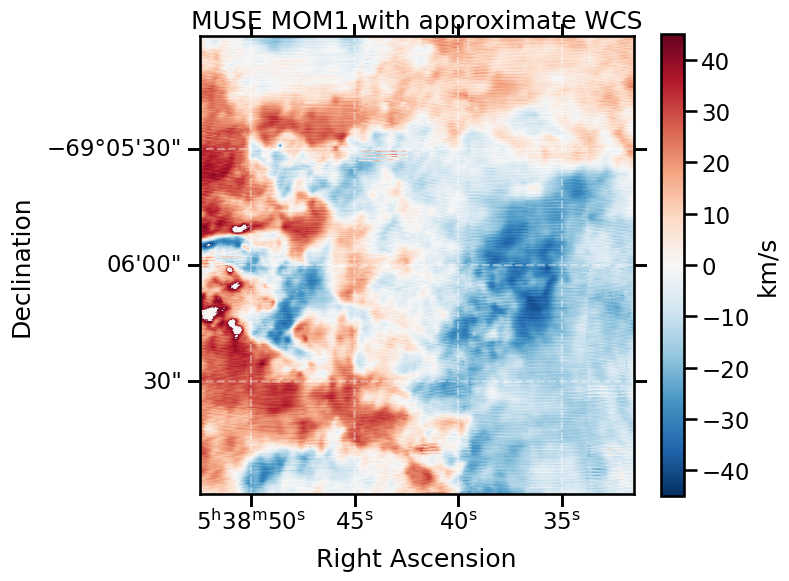

In [33]:
fig = plt.figure(figsize=(7, 6))

ax = fig.add_subplot(1, 1, 1, projection=wcs_muse)

im = ax.imshow(
    mom1-np.mean(mom1),
    origin="lower",
    cmap="RdBu_r",
    vmin=-45,
    vmax=45,
)


plt.colorbar(im, ax=ax, label="km/s")

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.set_title("MUSE MOM1 with approximate WCS")

ax.grid(color="white", alpha=0.4, linestyle="--")

plt.show()

In [18]:
ra_deg, dec_deg = wcs_muse.all_pix2world(
    df1["Y"].to_numpy(),  # x pixel coordinate
    df1["X"].to_numpy(),  # y pixel coordinate
    0                     # zero-based pixel convention
)

df1["RAdeg"] = ra_deg
df1["DEdeg"] = dec_deg

In [19]:
df1

,X,Y,V_mean,RAdeg,DEdeg
0,0,0,270.936814,84.718560,-69.116356
1,0,1,268.749784,84.718404,-69.116356
2,0,2,268.434771,84.718248,-69.116356
3,0,3,267.973044,84.718092,-69.116356
4,0,4,268.028558,84.717936,-69.116356
...,...,...,...,...,...
330395,589,555,278.646609,84.632128,-69.083634
330396,589,556,278.962284,84.631972,-69.083634
330397,589,557,278.595752,84.631817,-69.083633
330398,589,558,278.633191,84.631661,-69.083633


# WCS FP

In [20]:
mom1_fp = np.asarray(datasets["SAMFP"]["mom1"], dtype=np.float64)
df_fp = pd.DataFrame(mom1_fp)

df_fp = (
    df_fp.stack()
      .reset_index()
      .rename(columns={"level_0": "X", "level_1": "Y", 0: "V_mean"})
)

df_fp.describe()

,X,Y,V_mean
count,480233.000000,480233.000000,480233.000000
mean,344.000000,348.000000,275.662391
std,198.897165,201.206571,17.915796
min,0.000000,0.000000,220.078271
25%,172.000000,174.000000,262.602626
50%,344.000000,348.000000,274.655814
75%,516.000000,522.000000,286.884514
max,688.000000,696.000000,339.768510


In [21]:
center_fp = SkyCoord(
    "05h38m47.70s",
    "-69d05m43.0s",
    frame="icrs"
)

In [22]:
print(center_fp.ra.deg)
print(center_fp.dec.deg)

84.69874999999999
-69.09527777777777


In [23]:
# MUSE image array

# Array shape
ny, nx = mom1_fp.shape

# MUSE pixel scale
pixscale_arcsec = 0.18
pixscale_deg = pixscale_arcsec / 3600.0

# Approximate image center in sky coordinates
ra0 = center_fp.ra.deg
dec0 = center_fp.dec.deg

# Create WCS object
wcs_fp = WCS(naxis=2)

wcs_fp.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs_fp.wcs.crval = [ra0, dec0]

# FITS/WCS uses 1-based reference pixels
wcs_fp.wcs.crpix = [(nx + 1) / 2, (ny + 1) / 2]

# RA axis usually has negative pixel scale
wcs_fp.wcs.cdelt = [-pixscale_deg, pixscale_deg]

wcs_fp

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 84.69874999999999 -69.09527777777777 
CRPIX : 349.0 345.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -4.9999999999999996e-05 4.9999999999999996e-05 
NAXIS : 0  0

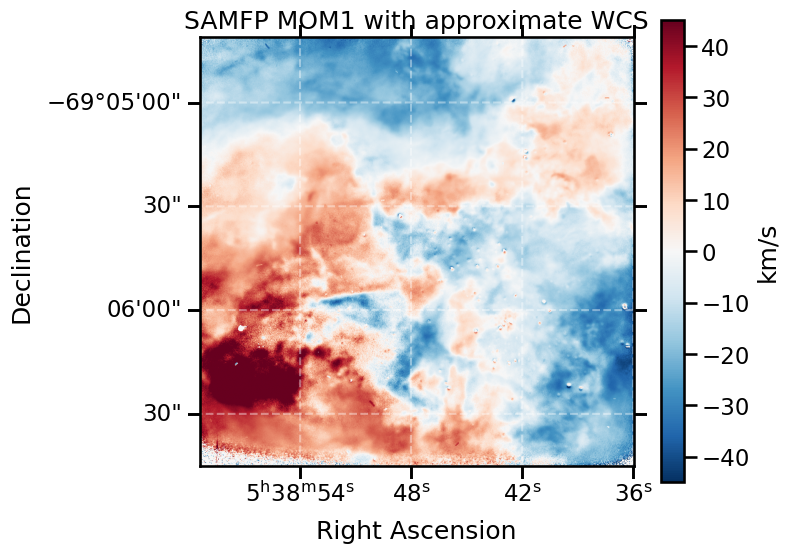

In [34]:
fig = plt.figure(figsize=(7, 6))

ax = fig.add_subplot(1, 1, 1, projection=wcs_fp)

im = ax.imshow(
    mom1_fp-np.mean(mom1_fp),
    origin="lower",
    cmap="RdBu_r",
    vmin=-45,
    vmax=45,

)

plt.colorbar(im, ax=ax, label="km/s")

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.set_title("SAMFP MOM1 with approximate WCS")

ax.grid(color="white", alpha=0.4, linestyle="--")

plt.show()

In [25]:
ra_deg, dec_deg = wcs_fp.all_pix2world(
    df_fp["Y"].to_numpy(),  # x pixel coordinate
    df_fp["X"].to_numpy(),  # y pixel coordinate
    0                     # zero-based pixel convention
)

df_fp["RAdeg"] = ra_deg
df_fp["DEdeg"] = dec_deg

In [26]:
df_fp.describe()

,X,Y,V_mean,RAdeg,DEdeg
count,480233.000000,480233.000000,480233.000000,480233.000000,480233.000000
mean,344.000000,348.000000,275.662391,84.698750,-69.095275
std,198.897165,201.206571,17.915796,0.028195,0.009945
min,0.000000,0.000000,220.078271,84.649947,-69.112478
25%,172.000000,174.000000,262.602626,84.674358,-69.103877
50%,344.000000,348.000000,274.655814,84.698750,-69.095276
75%,516.000000,522.000000,286.884514,84.723142,-69.086674
max,688.000000,696.000000,339.768510,84.747553,-69.078071


# Velocity fields comparison

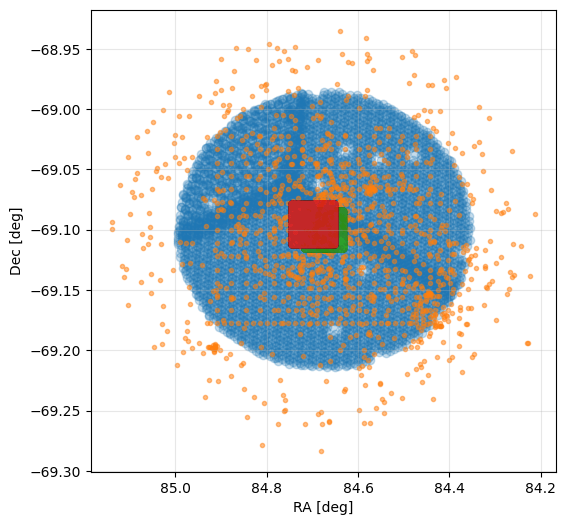

In [27]:
plt.figure(figsize=(6, 6))

plt.scatter(datasets['LVM_100']['frame_hdu1']['RAdeg'],datasets['LVM_100']['frame_hdu1']['DEdeg'], alpha = 0.25)
plt.scatter(datasets['FLA']['frame_hdu1']['RAdeg'],datasets['FLA']['frame_hdu1']['DEdeg'], alpha = 0.5, marker = '.')
plt.scatter(df1['RAdeg'],df1['DEdeg'], marker = '.', alpha = 0.05)
plt.scatter(df_fp['RAdeg'],df_fp['DEdeg'], marker = '.', alpha = 0.05)

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\javas\anaconda3\envs\viento\Lib\site-packages\astropy\visualization\wcsaxes\core.py:591: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(renderer)
C:\Users\javas\anaconda3\envs\viento\Lib\site-packages\astropy\visualization\wcsaxes\core.py:794: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  bb.append(super().get_tightbbox(renderer, *args, **kwargs))
C:\Users\javas\anaconda3\envs\viento\Lib\site-packages\astropy\visualization\wcsaxes\core.py:591: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(renderer)


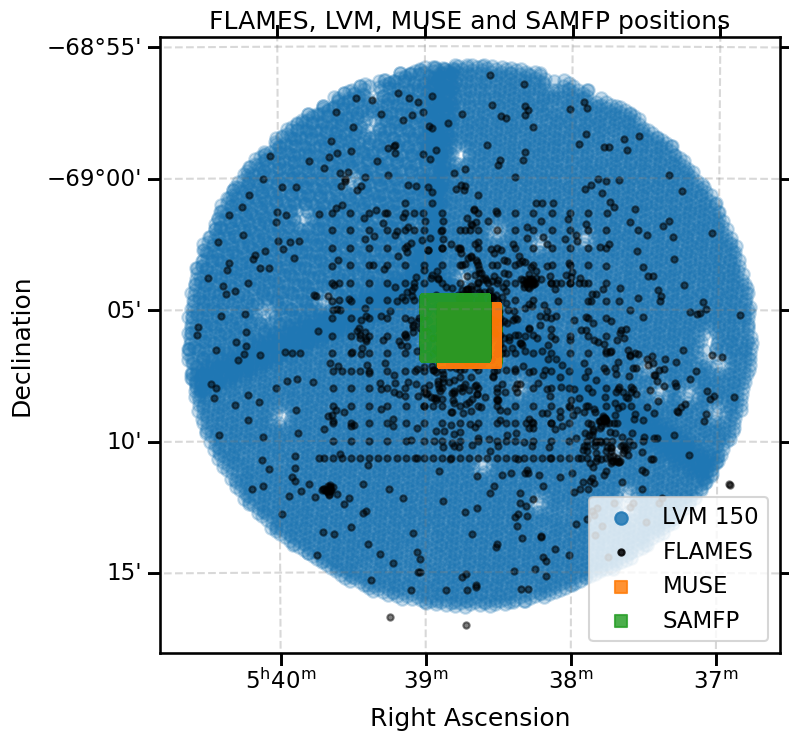

In [28]:

sns.set_context("talk")

# Approximate center of the field
ra0 = 84.675
dec0 = -69.1

# Create a simple WCS for plotting
wcs_plot = WCS(naxis=2)
wcs_plot.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs_plot.wcs.crval = [ra0, dec0]
wcs_plot.wcs.crpix = [1, 1]
wcs_plot.wcs.cdelt = [-1 / 3600, 1 / 3600]  # arbitrary 1 arcsec/pix for display frame

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=wcs_plot)

ax.scatter(
    datasets["LVM_150"]["frame_hdu1"]["RAdeg"],
    datasets["LVM_150"]["frame_hdu1"]["DEdeg"],
    alpha=0.25,
    label="LVM 150",
    transform=ax.get_transform("world"),
)

ax.scatter(
    datasets["FLA"]["frame_hdu1"]["RAdeg"],
    datasets["FLA"]["frame_hdu1"]["DEdeg"],
    alpha=0.5,
    label="FLAMES",
    marker=".",
    color = 'black',
    transform=ax.get_transform("world"),
)

ax.scatter(
    df1["RAdeg"],
    df1["DEdeg"],
    marker="s",
    alpha=0.10,
    label="MUSE",
    transform=ax.get_transform("world"),
)

ax.scatter(
    df_fp["RAdeg"],
    df_fp["DEdeg"],
    marker="s",
    alpha=0.10,
    label="SAMFP",
    transform=ax.get_transform("world"),
)


ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.set_title("FLAMES, LVM, MUSE and SAMFP positions")

leg = ax.legend()

for handle in leg.legend_handles:
    handle.set_alpha(0.85)

ax.grid(color="gray", alpha=0.3, linestyle="--")

plt.show()